In [22]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.model_selection import GridSearchCV

In [2]:
df = pd.read_csv('imdb_genres.csv', on_bad_lines="skip")
df.head()

,movie title - year,genre,expanded-genres,rating,description
0,Black Panther: Wakanda Forever - 2022,Action,"Action, Adventure, Drama",6.9,The people of Wakanda fight to protect their h...
1,Avatar: The Way of Water - 2022,Action,"Action, Adventure, Fantasy",7.8,Jake Sully lives with his newfound family form...
2,Plane - 2023,Action,"Action, Thriller",6.5,A pilot finds himself caught in a war zone aft...
3,Everything Everywhere All at Once - 2022,Action,"Action, Adventure, Comedy",8.0,A middle-aged Chinese immigrant is swept up in...
4,Fast X - 2023,Action,"Action, Crime, Mystery",NaN,Dom Toretto and his family are targeted by the...


In [3]:
del df["movie title - year"]
del df['expanded-genres']
del df['rating']

In [4]:
print("\nИнформация о данных:")
print(df.info())
print("\nПропущенные значения:")
print(df.isnull().sum())


Информация о данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300388 entries, 0 to 300387
Data columns (total 2 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   genre        300388 non-null  object
 1   description  300388 non-null  object
dtypes: object(2)
memory usage: 4.6+ MB
None

Пропущенные значения:
genre          0
description    0
dtype: int64


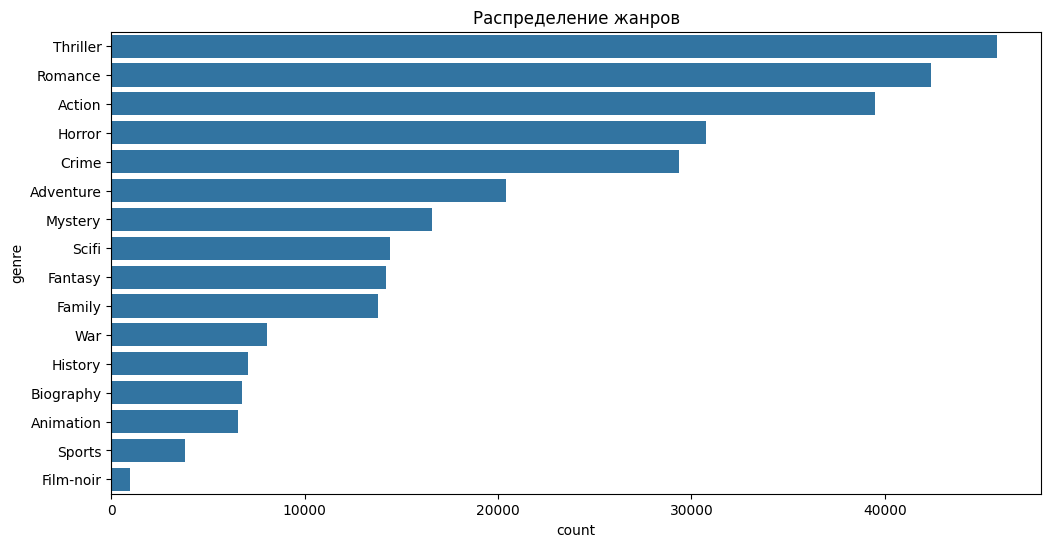


Количество уникальных жанров: 16
Самые частые жанры:
 genre
Thriller     45800
Romance      42376
Action       39514
Horror       30740
Crime        29338
Adventure    20422
Mystery      16578
Scifi        14412
Fantasy      14193
Family       13775
Name: count, dtype: int64


In [5]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, y='genre', order=df['genre'].value_counts().index)
plt.title("Распределение жанров")
plt.show()

print("\nКоличество уникальных жанров:", df['genre'].nunique())
print("Самые частые жанры:\n", df['genre'].value_counts().head(10))

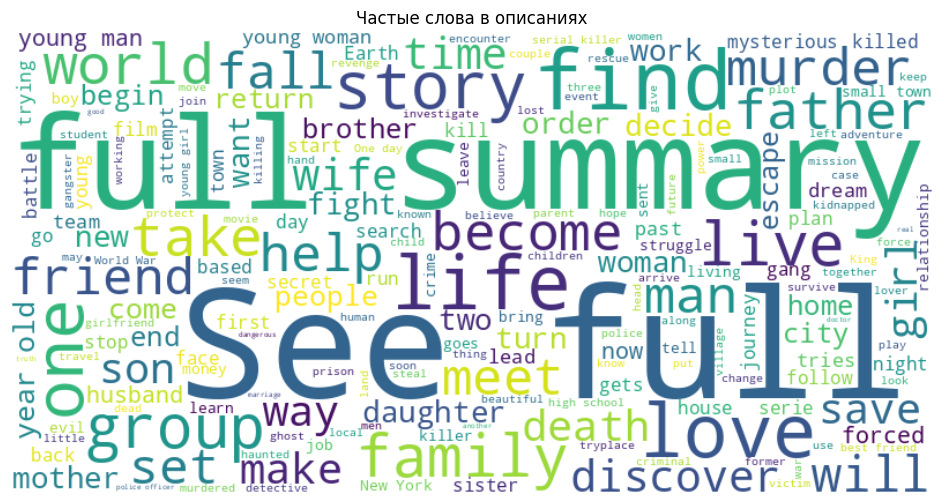

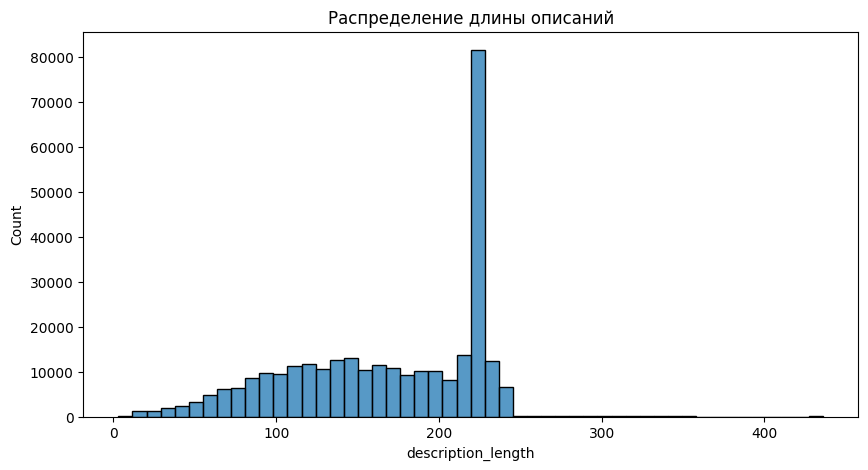

In [7]:
all_text = " ".join(df['description'].dropna())

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_text)
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Частые слова в описаниях")
plt.show()

df['description_length'] = df['description'].str.len()
plt.figure(figsize=(10, 5))
sns.histplot(df['description_length'], bins=50)
plt.title("Распределение длины описаний")
plt.show()

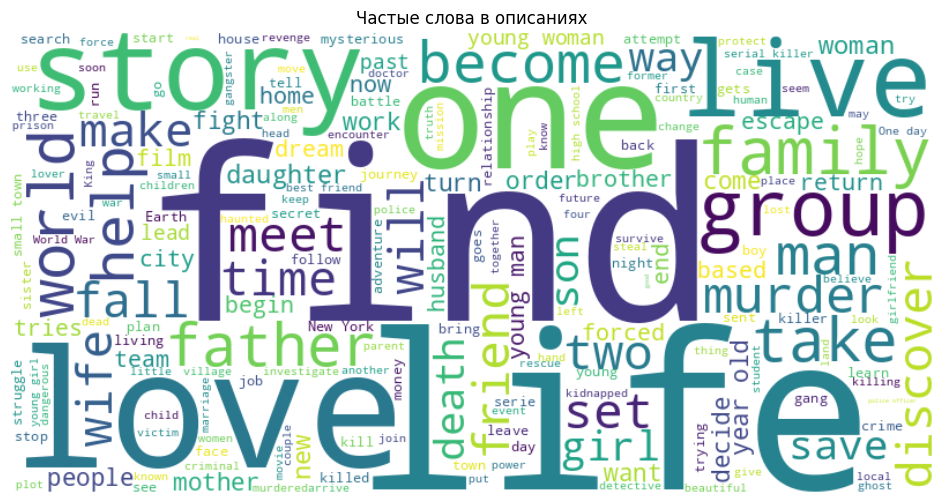

In [10]:
df['description'] = df['description'].apply(lambda x: re.sub(r'\s*see full summary.*$', '', x, flags=re.IGNORECASE))

all_text = " ".join(df['description'].dropna())

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_text)
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Частые слова в описаниях")
plt.show()

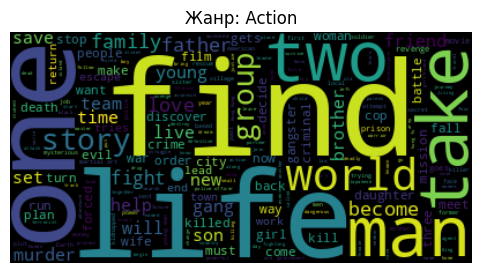

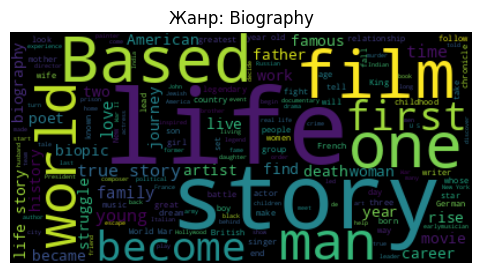

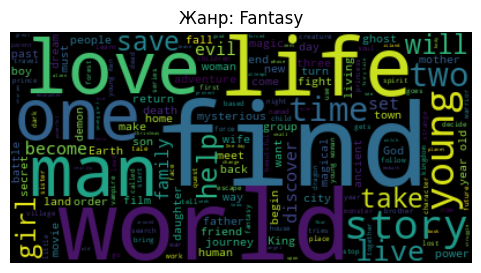

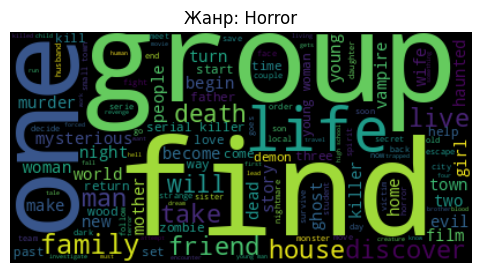

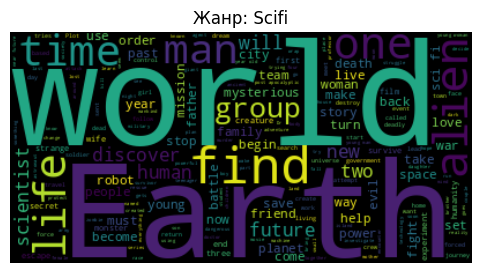

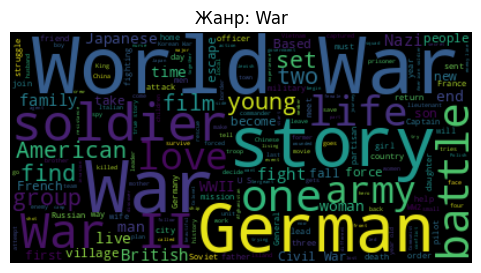

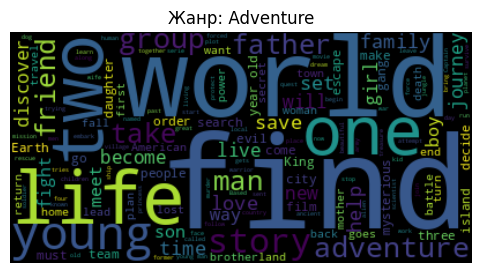

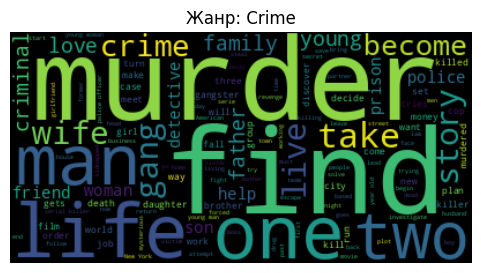

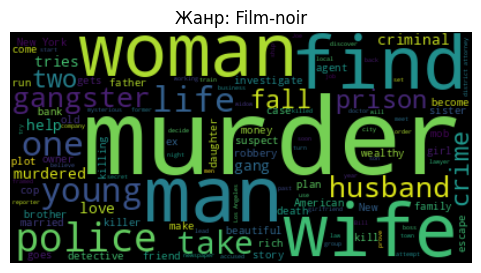

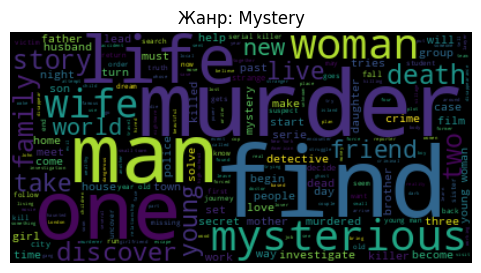

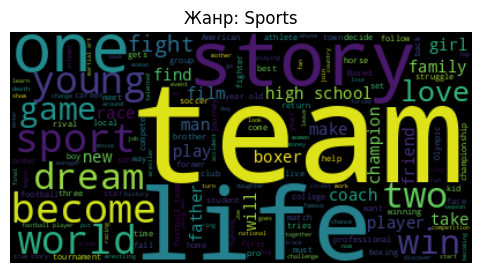

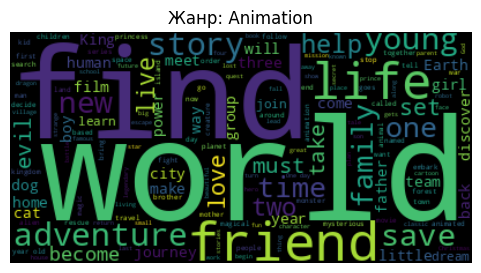

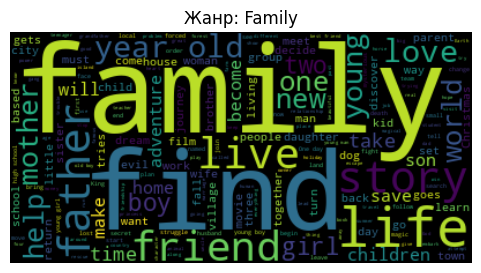

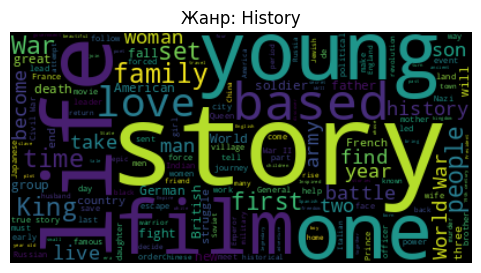

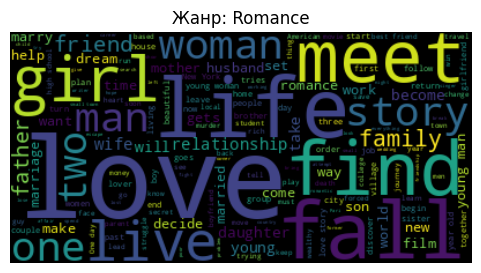

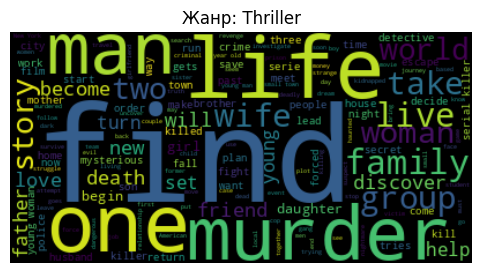

In [15]:
genres = df['genre'].unique()

for genre in genres:
    genre_text = " ".join(df[df['genre'] == genre]['description'].dropna())
    wordcloud = WordCloud(width=400, height=200).generate(genre_text)
    plt.figure(figsize=(6, 3))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title(f"Жанр: {genre}")
    plt.axis("off")
    plt.show()

In [13]:
df['genre'].unique()

array(['Action', 'Biography', 'Fantasy', 'Horror', 'Scifi', 'War',
       'Adventure', 'Crime', 'Film-noir', 'Mystery', 'Sports',
       'Animation', 'Family', 'History', 'Romance', 'Thriller'],
      dtype=object)

In [16]:
le = LabelEncoder()
df['genre'] = le.fit_transform(df['genre'])

genre_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print("Соответствие жанров и чисел:", genre_mapping)

Соответствие жанров и чисел: {'Action': np.int64(0), 'Adventure': np.int64(1), 'Animation': np.int64(2), 'Biography': np.int64(3), 'Crime': np.int64(4), 'Family': np.int64(5), 'Fantasy': np.int64(6), 'Film-noir': np.int64(7), 'History': np.int64(8), 'Horror': np.int64(9), 'Mystery': np.int64(10), 'Romance': np.int64(11), 'Scifi': np.int64(12), 'Sports': np.int64(13), 'Thriller': np.int64(14), 'War': np.int64(15)}


In [17]:
# Векторизация текста
tfidf = TfidfVectorizer(max_features=5000, stop_words='english')
X_tfidf = tfidf.fit_transform(df['description'])

# Разделение на тренировочный и тестовый наборы
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, df['genre'], test_size=0.2, random_state=42)

In [19]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Naive Bayes": MultinomialNB(),
    "Random Forest": RandomForestClassifier(n_estimators=100)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f"\n{name} Results:")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
    print(classification_report(y_test, y_pred))


Logistic Regression Results:
Accuracy: 0.35
              precision    recall  f1-score   support

           0       0.32      0.38      0.35      7890
           1       0.24      0.17      0.20      4049
           2       0.33      0.11      0.17      1315
           3       0.42      0.31      0.36      1347
           4       0.33      0.29      0.31      5891
           5       0.32      0.25      0.28      2776
           6       0.23      0.14      0.17      2787
           7       0.00      0.00      0.00       205
           8       0.27      0.15      0.19      1450
           9       0.42      0.47      0.45      6132
          10       0.20      0.06      0.09      3302
          11       0.44      0.65      0.52      8504
          12       0.33      0.30      0.31      2876
          13       0.46      0.36      0.40       791
          14       0.28      0.35      0.31      9140
          15       0.42      0.39      0.41      1623

    accuracy                       

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/m

KeyboardInterrupt: 

In [ ]:
params = {'C': [0.1, 1, 10], 'penalty': ['l2']}
grid = GridSearchCV(LogisticRegression(), params, cv=5)
grid.fit(X_train, y_train)
print("Best params:", grid.best_params_)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c